# 🕵️‍♂️ Fraud Detection: Interactive MLOps Pipeline

This notebook recreates the modular code found in the `src/` directory so you can learn interactively. We will walk through data cleaning, feature engineering, and model training.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data
We load the Kaggle Credit Card Fraud dataset.

In [2]:
df = pd.read_csv('../data/creditcard.csv')
print(f"Data shape: {df.shape}")
df.head()

Data shape: (284807, 30)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Data Cleaning
Removing duplicates and handling basic missing values.

In [3]:
initial_shape = df.shape
df = df.drop_duplicates()
print(f"Dropped {initial_shape[0] - df.shape[0]} duplicate rows.")

if df.isnull().sum().sum() > 0:
    df = df.fillna(df.median())
    print("Filled missing values.")

Dropped 9144 duplicate rows.


## 3. Feature Engineering
The PCA features (V1-V28) are already scaled, but the `Amount` feature is untransformed and contains outliers. We apply `RobustScaler`.

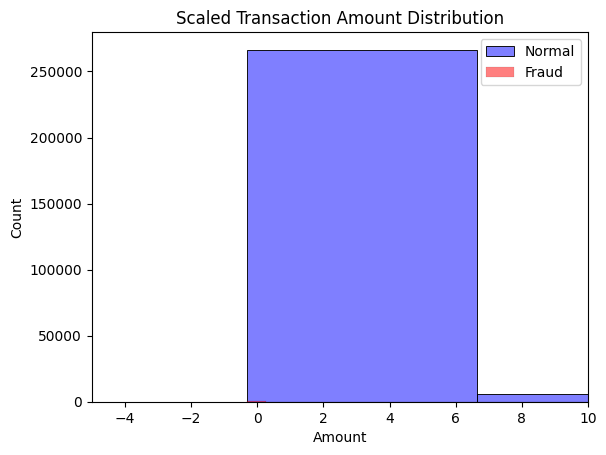

In [4]:
scaler = RobustScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Check the distribution after scaling
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='blue', alpha=0.5, label='Normal')
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', alpha=0.5, label='Fraud')
plt.xlim(-5, 10)
plt.legend()
plt.title("Scaled Transaction Amount Distribution")
plt.show()

## 4. Model Training (Handling Imbalance)
Fraud is <0.5% of the data. We use `scale_pos_weight` in XGBoost to penalize missed frauds heavily.

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scale_pos_weight = y_train.value_counts()[0] / (y_train.value_counts()[1] + 1)
print(f"Scale pos weight calculated as: {scale_pos_weight:.2f}")

clf = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

clf.fit(X_train, y_train)

Scale pos weight calculated as: 580.88


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 5. Evaluation
Instead of accuracy, we rely on Average Precision (AUPRC) and F1-Score to judge performance on imbalanced data.

In [6]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

auprc = average_precision_score(y_test, y_proba)
print(f"AUPRC: {auprc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

AUPRC: 0.7616

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.42      0.85      0.56        95

    accuracy                           1.00     55133
   macro avg       0.71      0.93      0.78     55133
weighted avg       1.00      1.00      1.00     55133

